In [115]:
import pandas as pd
import plotly.express as px
import numpy as np
import pdb
import seaborn as sns
from matplotlib import pyplot as plt
import os
import plotly.graph_objects as go

df_trio = pd.read_csv("data/coronal_CTBLabelled_dataset.csv")
df_pfc = pd.read_csv("data/PFC_TRIO_cellcounts.csv")

## 3D Spatial Distribution of TRIO-labelled Cells

**Explanation:**
This figure shows the spatial distribution of TRIO-labelled neurons in AP, ML, and DV coordinates. It allows visualisation of the overall anatomical spread and overlap of projection-defined populations (PFC, NAc, LH).

In [98]:
fig = px.scatter_3d(df_trio, x="AP", y="ML", z="DV", color="Projection", 
    color_discrete_map={"PFC": "#FFDB6E", "NAc": "#BF43CC", "LH": "#87FFE1"})

fig.update_traces(marker_size=2, opacity=0.25)

axis_style = dict(showbackground=True, backgroundcolor="#3D3838", gridcolor="gray", color="#B3A7A7")

fig.update_layout(width=1200, height=800, autosize=False, legend=dict(bgcolor="gray", bordercolor="rgba(0,0,0,0.2)", 
    borderwidth=1, font=dict(size=12),title=dict(text="Projection")), paper_bgcolor="#2A2525", plot_bgcolor="black",    
    font=dict(color="black"),  scene=dict(xaxis=axis_style, yaxis=axis_style, zaxis=axis_style, bgcolor="#2A2525"))

fig.show()

## Projection composition along the anterior–posterior axis (vS cells)

Cells were restricted to the ventral subiculum population (SUBv-sp) and analysed along the anterior–posterior (AP) axis. The AP axis was divided into bins, and within each bin the proportion of cells projecting to PFC, NAc, and LH was calculated.

This analysis shows how projection identity varies locally across the AP axis, revealing a graded organisation rather than discrete boundaries. Differences in the relative proportions of projections across bins indicate spatial biases in connectivity within the ventral subiculum.

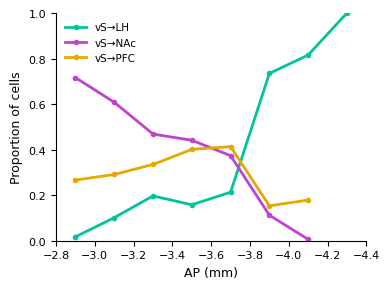

In [ ]:
df_trio = df_trio[df_trio['acronym'] == 'SUBv-sp']

bins = np.arange(-4.4, -2.6, 0.2)
df_trio["AP_bin"] = pd.cut(df_trio["AP"], bins)

counts = df_trio.groupby(["AP_bin", "Projection"]).size().reset_index(name="count")
counts["AP_center"] = counts["AP_bin"].apply(lambda x: x.mid)
counts["prop"] = counts.groupby("AP_center")["count"].transform(lambda x: x / x.sum())

colors = {"PFC": "#E6A800", "NAc": "#BF43CC", "LH": "#00C49A"}
labels = {"PFC": "vS→PFC", "NAc": "vS→NAc", "LH": "vS→LH"}

fig, ax = plt.subplots(figsize=(4, 3))

for proj in ["LH", "NAc", "PFC"]:
    data = counts[counts["Projection"] == proj].sort_values("AP_center")
    ax.plot(data["AP_center"], data["prop"],
            color=colors[proj], lw=2, label=labels[proj],
            marker='o', markersize=3)

ax.set_xlim(-2.8, -4.4)
ax.set_ylim(0, 1)
ax.set_xlabel("AP (mm)", fontsize=9)
ax.set_ylabel("Proportion of cells", fontsize=9)
ax.tick_params(labelsize=8)
ax.legend(fontsize=7.5, frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()
